# Hierarchical Gaussian Models

**Prerequisites:** This chapter builds on [Bayesian Modeling](01_01_bayes), [Bayesian Analysis of the Normal Distribution](01_02_normal), [Multivariate Normal](01_03_mvn), and [Probabilistic Graphical Models](01_04_pgms).

This lecture works through exact Bayesian inference in a **hierarchical Gaussian
model** — a multi-level model that pools information across groups. The running
example is the *Eight Schools* dataset from {cite}`gelman2013bayesian`, used as a
benchmark by many probabilistic programming systems.

The model places a shared prior over school-level means, allowing estimates to
borrow strength from one another while still respecting per-school data. Because
the model is conditionally linear and Gaussian, the posterior can be computed
exactly by sequential marginalization — making this one of the most complex models
for which closed-form inference is still achievable.

In this lecture we cover:
- The hierarchical Gaussian model and its graphical representation
- Sequential marginalization: $p(\mbtheta \mid \cdot)$, $p(\mu \mid \tau^2, \cdot)$, $p(\tau^2 \mid \cdot)$
- Numerical normalization of the one-dimensional marginal $p(\tau^2 \mid \mbX)$
- Posterior sampling via ancestral sampling
- Comparison to classical ANOVA / partial pooling

:::{admonition} Reading
:class: reading
{cite}`murphy2023probabilistic`, Ch 4.2.
See also: {cite}`gelman2013bayesian`, Ch 5.
:::

In [10]:
import torch
from torch.distributions import Normal, Gamma, Categorical, TransformedDistribution
from torch.distributions.transforms import PowerTransform
import matplotlib.pyplot as plt
from matplotlib.cm import Blues
import seaborn as sns
sns.set_context("notebook")


class ScaledInvChiSq(TransformedDistribution):
    """Scaled inverse chi-squared: χ⁻²(ν, σ²).

    Equivalent to IGa(ν/2, νσ²/2). Implemented as a transformation of Gamma.
    """
    def __init__(self, ν, σ2):
        base = Gamma(ν / 2, ν * σ2 / 2)
        TransformedDistribution.__init__(self, base, [PowerTransform(-1)])
        self.ν  = ν
        self.σ2 = σ2

## Motivation

Data are often organized into groups — students within schools, patients within hospitals, experiments within labs. The individual observations within a group are *not* exchangeable with those in other groups (because group membership matters), but the groups themselves may be exchangeable.

**Hierarchical models** handle this by introducing group-level parameters $\theta_s$ (one per group $s$), drawn i.i.d. from a shared population distribution. Group-level parameters explain within-group variation, while the population distribution allows information to be shared across groups.

:::{admonition} Example: Test scores across schools
:class: tip
Suppose we have test scores from $S$ schools. Let $N_s$ denote the number of students from school $s$ and $x_{s,n} \in \reals$ denote the score of student $n$ in school $s$. We want to estimate each school's mean performance $\theta_s$, but most schools have small $N_s$ so individual estimates are noisy.
:::

The key insight is that the scores within each school are *not* exchangeable with those across schools, but the schools themselves are exchangeable. This motivates the following hierarchical model:

\begin{align}
    \mu, \tau^2 &\sim p(\mu, \tau^2), \\
    \theta_s \mid \mu, \tau^2 &\iid{\sim} \cN(\mu, \tau^2), \quad s = 1, \ldots, S, \\
    x_{s,n} \mid \theta_s &\iid{\sim} \cN(\theta_s, \sigma_s^2), \quad n = 1, \ldots, N_s.
\end{align}

Each school has its own mean $\theta_s$, drawn from a global distribution with mean $\mu$ and variance $\tau^2$. The **global mean** $\mu$ captures the overall population effect; the **global variance** $\tau^2$ controls how much schools differ from each other.

For the prior on $(\mu, \tau^2)$, we use a normal-inverse-chi-squared distribution (as in Lecture 2 but for the scalar case):
\begin{align}
    p(\mu, \tau^2) &= \mathrm{NIX}(\mu, \tau^2 \mid \mu_0, \kappa_0, \nu_0, \tau_0^2)
    = \cN(\mu \mid \mu_0, \tau^2 / \kappa_0) \, \chi^{-2}(\tau^2 \mid \nu_0, \tau_0^2).
\end{align}
The hyperparameters are $\boldsymbol{\eta} = (\mu_0, \kappa_0, \nu_0, \tau_0^2, \{\sigma_s^2\}_{s=1}^S)$.

### The Eight Schools Dataset

We illustrate with a classic dataset from {cite}`gelman2013bayesian`, Ch 5.5, also used as a benchmark by probabilistic programming systems such as Stan and NumPyro. Eight schools participated in a study of an SAT coaching program. For each school $s$, we are given the estimated treatment effect $\bar{x}_s$ (the difference in mean SAT scores between coached and uncoached students) and its standard error $\bar{\sigma}_s$.

| School | $\bar{x}_s$ | $\bar{\sigma}_s$ |
|--------|------------|-----------------|
| A | 28 | 15 |
| B | 8 | 10 |
| C | −3 | 16 |
| D | 7 | 11 |
| E | −1 | 9 |
| F | 1 | 11 |
| G | 18 | 10 |
| H | 12 | 18 |

The standard errors $\bar{\sigma}_s$ are treated as known (they are themselves estimates from each school's data, but we condition on them for simplicity). We set weakly informative hyperparameters: $\mu_0 = 0$, $\kappa_0 = 0.1$, $\nu_0 = 0.1$, and $\tau_0^2 = 100$.

In [11]:
torch.manual_seed(305)

S = 8                        # number of schools

# Hyperparameters
μ0   = torch.tensor(0.0)     # prior mean of global effect
κ0   = torch.tensor(0.1)     # prior concentration (NIX)
ν0   = torch.tensor(0.1)     # degrees of freedom (NIX)
τ2_0 = torch.tensor(100.0)   # prior scale of global variance

# Observed school-level sample means and standard errors
x_bars  = torch.tensor([28., 8., -3., 7., -1., 1., 18., 12.])
σ_bars  = torch.tensor([15., 10., 16., 11., 9., 11., 10., 18.])

## Bayesian Inference in the Hierarchical Gaussian Model

Our goal is to compute the joint posterior,
\begin{align}
    p(\mu, \tau^2, \mbtheta \mid \mbX, \boldsymbol{\eta}),
\end{align}
where $\mbtheta = (\theta_1, \ldots, \theta_S)$. We proceed by sequential marginalization, decomposing the posterior using the product rule:
\begin{align}
    p(\mu, \tau^2, \mbtheta \mid \mbX, \boldsymbol{\eta})
    &= p(\mbtheta \mid \mu, \tau^2, \mbX, \boldsymbol{\eta}) \;
       p(\mu \mid \tau^2, \mbX, \boldsymbol{\eta}) \;
       p(\tau^2 \mid \mbX, \boldsymbol{\eta}).
\end{align}
We will compute each factor in turn.

### Step 1: Sufficient Statistics

As a function of $\theta_s$, the likelihood for school $s$ depends on the data only through the school mean $\bar{x}_s = \frac{1}{N_s}\sum_n x_{s,n}$:
\begin{align}
    \prod_{n=1}^{N_s} \cN(x_{s,n} \mid \theta_s, \sigma_s^2)
    &\propto \cN(\bar{x}_s \mid \theta_s, \bar{\sigma}_s^2),
\end{align}
where $\bar{\sigma}_s^2 = \sigma_s^2 / N_s$ is the variance of the school mean. The school mean is thus a **sufficient statistic** for $\theta_s$. In the Eight Schools dataset, $\bar{x}_s$ and $\bar{\sigma}_s$ are given directly.

### Step 2: Per-School Posteriors (given $\mu$ and $\tau^2$)

The per-school parameters $\theta_s$ are conditionally independent given $(\mu, \tau^2)$, so the posterior factors:
\begin{align}
    p(\mbtheta \mid \mu, \tau^2, \mbX, \boldsymbol{\eta})
    &= \prod_{s=1}^S p(\theta_s \mid \mu, \tau^2, \bar{x}_s).
\end{align}
Each factor is a product of a Gaussian prior and a Gaussian likelihood, so by the results of Lecture 1,
\begin{align}
    p(\theta_s \mid \mu, \tau^2, \bar{x}_s) &= \cN(\theta_s \mid \hat{\theta}_s, v_s),
\end{align}
where
\begin{align}
    v_s &= \left(\frac{1}{\bar{\sigma}_s^2} + \frac{1}{\tau^2}\right)^{-1},
    \qquad
    \hat{\theta}_s = v_s \left(\frac{\bar{x}_s}{\bar{\sigma}_s^2} + \frac{\mu}{\tau^2}\right).
\end{align}
The conditional posterior mean $\hat{\theta}_s$ is a precision-weighted average of the school observation $\bar{x}_s$ and the global mean $\mu$. When $\tau^2$ is large (schools vary a lot), the school mean dominates; when $\tau^2$ is small, the global mean dominates — this is the **shrinkage** or **partial pooling** effect.

### Step 3: Posterior of the Global Mean (given $\tau^2$)

To find $p(\mu \mid \tau^2, \mbX, \boldsymbol{\eta})$, we integrate over $\mbtheta$. Because each $\theta_s$ enters the model linearly, the integral is tractable via the linear Gaussian model results from Lecture 2:
\begin{align}
    p(\mu \mid \tau^2, \mbX, \boldsymbol{\eta})
    &\propto \cN(\mu \mid \mu_0, \tau^2/\kappa_0)
      \prod_{s=1}^S \int \cN(\theta_s \mid \mu, \tau^2)\, \cN(\bar{x}_s \mid \theta_s, \bar{\sigma}_s^2)\, \dif\theta_s \\
    &= \cN(\mu \mid \mu_0, \tau^2/\kappa_0) \prod_{s=1}^S \cN(\bar{x}_s \mid \mu, \bar{\sigma}_s^2 + \tau^2).
\end{align}
Each integral collapses $\theta_s$ by the linear Gaussian marginalization formula: $\bar{x}_s \mid \mu \sim \cN(\mu, \bar{\sigma}_s^2 + \tau^2)$.

Collecting terms quadratic and linear in $\mu$ and completing the square gives,
\begin{align}
    p(\mu \mid \tau^2, \mbX, \boldsymbol{\eta}) &= \cN(\mu \mid \hat{\mu}, v_\mu),
\end{align}
where
\begin{align}
    \lambda_0 &= \kappa_0 / \tau^2, \quad
    \lambda_s = 1 / (\bar{\sigma}_s^2 + \tau^2), \\
    v_\mu &= \frac{1}{\lambda_0 + \sum_s \lambda_s}, \quad
    \hat{\mu} = v_\mu \!\left(\lambda_0 \mu_0 + \sum_s \lambda_s \bar{x}_s\right).
\end{align}
The posterior mean $\hat{\mu}$ is a **precision-weighted average** of the prior mean $\mu_0$ and the school means $\bar{x}_s$. Schools with smaller total variance $\bar{\sigma}_s^2 + \tau^2$ (i.e. more precisely measured and more similar to the global mean) receive more weight.

In [12]:
def compute_posterior_mu(τ2, μ0, κ0, x_bars, σ_bars):
    """Posterior mean and variance of μ given τ² and data.

    Returns (μ_hat, v_μ), each of shape (T,) for a length-T tensor of τ² values.
    """
    λ0    = κ0 / τ2                                         # (T,)
    λs    = 1 / (σ_bars[None, :]**2 + τ2[:, None])         # (T, S)
    v_μ   = 1 / (λ0 + λs.sum(-1))                          # (T,)
    μ_hat = v_μ * (λ0 * μ0 + (λs * x_bars[None, :]).sum(-1))
    return μ_hat, v_μ

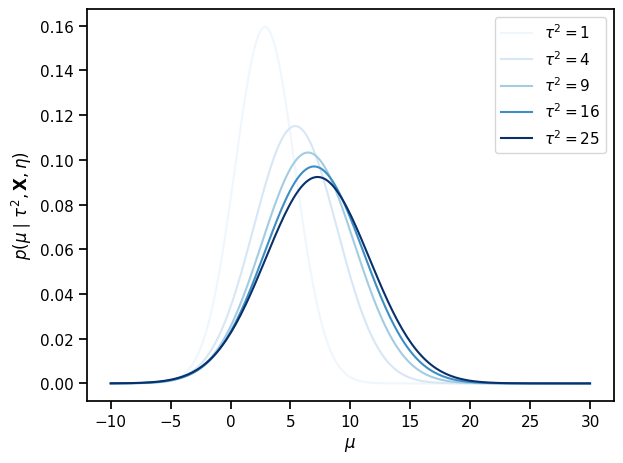

In [13]:
τ2s = torch.tensor([1., 4., 9., 16., 25.])
μ_hat, v_μ = compute_posterior_mu(τ2s, μ0, κ0, x_bars, σ_bars)

μ_grid = torch.linspace(-10, 30, 200)
fig, ax = plt.subplots()
for τ2, mean, var in zip(τ2s, μ_hat, v_μ):
    ax.plot(μ_grid,
            torch.exp(Normal(mean, torch.sqrt(var)).log_prob(μ_grid)),
            color=Blues((τ2 / τ2s.max()).item()),
            label=r"$\tau^2 = {:.0f}$".format(τ2))
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$p(\mu \mid \tau^2, \mathbf{X}, {\eta})$")
ax.legend()
plt.tight_layout()

### Step 4: Marginal Posterior of $\tau^2$

The last and hardest term is the **marginal posterior** of $\tau^2$, obtained by integrating out $\mu$:
\begin{align}
    p(\tau^2 \mid \mbX, \boldsymbol{\eta})
    &\propto \int p(\mu, \tau^2, \mbX \mid \boldsymbol{\eta})\, \dif\mu.
\end{align}
Rather than evaluating this integral directly, we use a trick: by Bayes' rule,
\begin{align}
    p(\tau^2 \mid \mbX, \boldsymbol{\eta})
    &= \frac{p(\mu, \tau^2 \mid \mbX, \boldsymbol{\eta})}{p(\mu \mid \tau^2, \mbX, \boldsymbol{\eta})},
\end{align}
which holds for *any* choice of $\mu$. Substituting the known expressions and evaluating at $\mu = \hat{\mu}$ (which cancels the denominator's exponential term), we obtain an unnormalized function,
\begin{align}
    f(\tau^2) \triangleq p(\tau^2) \cdot \frac{\sqrt{v_\mu}}{\tau}
    \cdot e^{-\frac{\kappa_0}{2\tau^2}(\hat{\mu} - \mu_0)^2}
    \cdot \prod_{s=1}^S \frac{1}{\sqrt{\bar{\sigma}_s^2 + \tau^2}}
    \exp\!\left(-\frac{(\bar{x}_s - \hat{\mu})^2}{2(\bar{\sigma}_s^2 + \tau^2)}\right),
\end{align}
where both $\hat{\mu}$ and $v_\mu$ depend on $\tau^2$. This function has no closed form, but since $\tau^2$ is one-dimensional we can evaluate it on a dense grid and normalize numerically.

In [14]:
def compute_log_f(τ2, x_bars, σ_bars, μ0, κ0, ν0, τ2_0):
    """Compute log f(τ²) — the unnormalized log marginal posterior of τ².

    Args:
        τ2:     (T,) tensor of τ² grid values
        x_bars: (S,) observed school means
        σ_bars: (S,) school standard errors
        μ0, κ0, ν0, τ2_0: NIX hyperparameters

    Returns:
        (T,) tensor of log f(τ²) values
    """
    # Prior on τ²
    log_f = ScaledInvChiSq(ν0, τ2_0).log_prob(τ2)

    # Posterior on μ | τ²  (derived in Step 3)
    λ0    = κ0 / τ2
    λs    = 1 / (σ_bars[None, :]**2 + τ2[:, None])         # (T, S)
    v_μ   = 1 / (λ0 + λs.sum(-1))
    μ_hat = v_μ * (λ0 * μ0 + (λs * x_bars[None, :]).sum(-1))

    # Bayes-rule trick: evaluate at μ = μ_hat
    log_f += 0.5 * torch.log(v_μ) - 0.5 * torch.log(τ2)
    log_f += -0.5 * κ0 / τ2 * (μ_hat - μ0)**2
    log_f += 0.5 * torch.log(λs).sum(-1)
    log_f += -0.5 * (λs * (x_bars[None, :] - μ_hat[:, None])**2).sum(-1)

    return log_f

In [15]:
τ2_grid = torch.linspace(1e-1, 256, 1000)

log_f   = compute_log_f(τ2_grid, x_bars, σ_bars, μ0, κ0, ν0, τ2_0)
dτ2     = τ2_grid[1] - τ2_grid[0]
p_τ2    = torch.exp(log_f - torch.logsumexp(log_f, 0) - torch.log(dτ2))

# Change of variables to get p(τ)
τ_grid  = torch.sqrt(τ2_grid)
p_τ     = 2 * p_τ2 * τ_grid

τ_mean  = (p_τ[:-1] * torch.diff(τ_grid) * τ_grid[:-1]).sum()
τ_var   = (p_τ[:-1] * torch.diff(τ_grid) * (τ_grid[:-1] - τ_mean)**2).sum()
print(f"Posterior  E[τ] = {τ_mean:.2f},  Std[τ] = {τ_var.sqrt():.2f}")

Posterior  E[τ] = 4.46,  Std[τ] = 2.54


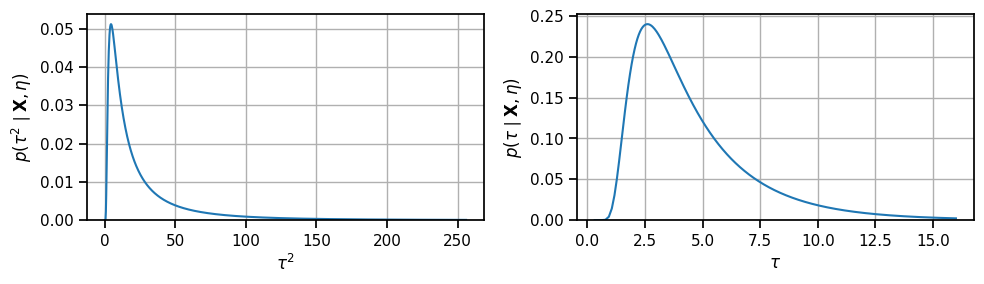

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(τ2_grid, p_τ2)
axes[0].set_xlabel(r"$\tau^2$")
axes[0].set_ylabel(r"$p(\tau^2 \mid \mathbf{X}, {\eta})$")
axes[0].set_ylim(0)
axes[0].grid(True)

axes[1].plot(τ_grid, p_τ)
axes[1].set_xlabel(r"$\tau$")
axes[1].set_ylabel(r"$p(\tau \mid \mathbf{X}, {\eta})$")
axes[1].set_ylim(0)
axes[1].grid(True)

plt.tight_layout()

### Step 5: Per-School Effects Marginalizing over $\mu$

Finally, we want the marginal posterior of each $\theta_s$ given $\tau^2$ and the data, having integrated out $\mu$. Using the product rule,
\begin{align}
    p(\theta_s \mid \tau^2, \mbX, \boldsymbol{\eta})
    &= \int p(\theta_s \mid \mu, \tau^2, \bar{x}_s) \, p(\mu \mid \tau^2, \mbX, \boldsymbol{\eta}) \, \dif\mu.
\end{align}
Both factors are Gaussian in $\mu$, so the integral is again tractable via linear Gaussian marginalization:
\begin{align}
    p(\theta_s \mid \tau^2, \mbX, \boldsymbol{\eta}) &= \cN(\theta_s \mid \hat{\theta}_s, v_{\theta_s}),
\end{align}
where
\begin{align}
    v_{\theta_s} &= \left(\frac{1}{\bar{\sigma}_s^2} + \frac{1}{\tau^2 + v_\mu}\right)^{-1},
    \qquad
    \hat{\theta}_s = v_{\theta_s}\left(\frac{\bar{x}_s}{\bar{\sigma}_s^2} + \frac{\hat{\mu}}{\tau^2 + v_\mu}\right).
\end{align}
The additional $v_\mu$ term in the denominator inflates the effective variance of the prior on $\theta_s$, reflecting our residual uncertainty about $\mu$.

In [17]:
def compute_posterior_theta(τ2, μ, x_bars, σ_bars):
    """Posterior mean/variance of θ_s given τ², μ, and data.

    Broadcasts over (T,) tensors of τ² and μ.
    Returns (θ_hat, v_θ) each of shape (T, S).
    """
    v_θ   = 1 / (1/σ_bars[None,:]**2 + 1/τ2[:,None])
    θ_hat = v_θ * (x_bars[None,:]/σ_bars[None,:]**2 + μ[:,None]/τ2[:,None])
    return θ_hat, v_θ


def compute_posterior_theta_marg(τ2, μ0, κ0, x_bars, σ_bars):
    """Posterior mean/variance of θ_s given τ², marginalizing over μ.

    Returns (θ_hat, v_θ) each of shape (T, S).
    """
    μ_hat, v_μ = compute_posterior_mu(τ2, μ0, κ0, x_bars, σ_bars)
    v_θ   = 1 / (1/σ_bars[None,:]**2 + 1/(τ2[:,None] + v_μ[:,None]))
    θ_hat = v_θ * (x_bars[None,:]/σ_bars[None,:]**2
                   + μ_hat[:,None]/(τ2[:,None] + v_μ[:,None]))
    return θ_hat, v_θ

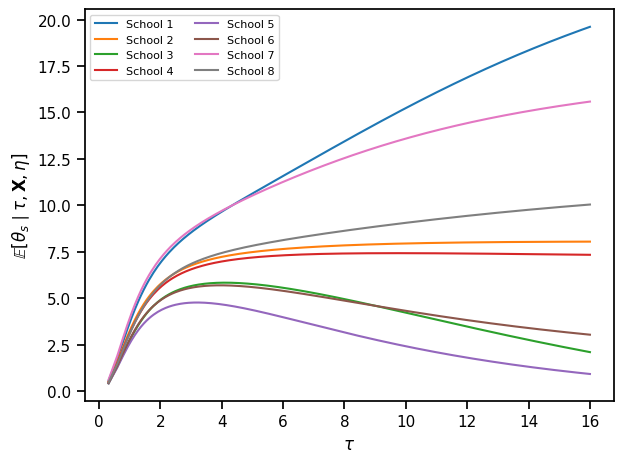

In [18]:
θ_hat, v_θ = compute_posterior_theta_marg(τ2_grid, μ0, κ0, x_bars, σ_bars)

fig, ax = plt.subplots()
for s in range(S):
    ax.plot(τ_grid, θ_hat[:, s], label=f"School {s+1}")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$\mathbb{E}[\theta_s \mid \tau, \mathbf{X}, {\eta}]$")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()

## Posterior Sampling via Ancestral Sampling

We now have all the pieces needed to draw samples from the joint posterior $p(\mu, \tau^2, \mbtheta \mid \mbX, \boldsymbol{\eta})$. Because we computed the posterior in the order $\tau^2 \to \mu \to \mbtheta$ (by sequential marginalization), we can draw samples in the reverse order — this is called **ancestral sampling**:

1. **Sample $\tau$** from the normalized grid approximation $p(\tau \mid \mbX, \boldsymbol{\eta})$.
2. **Sample $\mu$** from the conditional $p(\mu \mid \tau^2, \mbX, \boldsymbol{\eta}) = \cN(\hat{\mu}, v_\mu)$.
3. **Sample $\mbtheta$** from $p(\mbtheta \mid \mu, \tau^2, \mbX, \boldsymbol{\eta}) = \prod_s \cN(\hat{\theta}_s, v_s)$.

Discarding $\tau$ and $\mu$ from each sample gives draws from the marginal posterior $p(\mbtheta \mid \mbX, \boldsymbol{\eta})$.

In [19]:
torch.manual_seed(305)
N_samp = 10000

# Step 1: sample τ from the discrete grid approximation
centers = 0.5 * (τ_grid[:-1] + τ_grid[1:])
widths  = torch.diff(τ_grid)
inds    = Categorical(probs=p_τ[:-1] * widths).sample((N_samp,))
τ_samp  = centers[inds]                                  # (N_samp,)

# Step 2: sample μ | τ²
μ_hat, v_μ = compute_posterior_mu(τ_samp**2, μ0, κ0, x_bars, σ_bars)
μ_samp = Normal(μ_hat, torch.sqrt(v_μ)).sample()        # (N_samp,)

# Step 3: sample θ_s | μ, τ²
θ_hat, v_θ = compute_posterior_theta(τ_samp**2, μ_samp, x_bars, σ_bars)
θ_samp = Normal(θ_hat, torch.sqrt(v_θ)).sample()        # (N_samp, S)

# Posterior summary statistics
print(f"{'School':>8}  {'mean':>7}  {'std':>6}  {'5%':>7}  {'95%':>7}")
print("-" * 42)
for s in range(S):
    print(f"{s+1:>8}  "
          f"{θ_samp[:,s].mean():>7.2f}  "
          f"{θ_samp[:,s].std():>6.2f}  "
          f"{torch.quantile(θ_samp[:,s], 0.05):>7.2f}  "
          f"{torch.quantile(θ_samp[:,s], 0.95):>7.2f}")

  School     mean     std       5%      95%
------------------------------------------
       1     8.65    6.46    -0.51    20.19
       2     6.81    5.38    -1.73    15.80
       3     5.75    5.94    -3.83    15.45
       4     6.75    5.56    -1.91    16.11
       5     5.05    5.19    -3.78    13.32
       6     5.81    5.48    -3.09    14.79
       7     8.59    5.79    -0.02    18.78
       8     6.99    6.24    -2.72    17.45


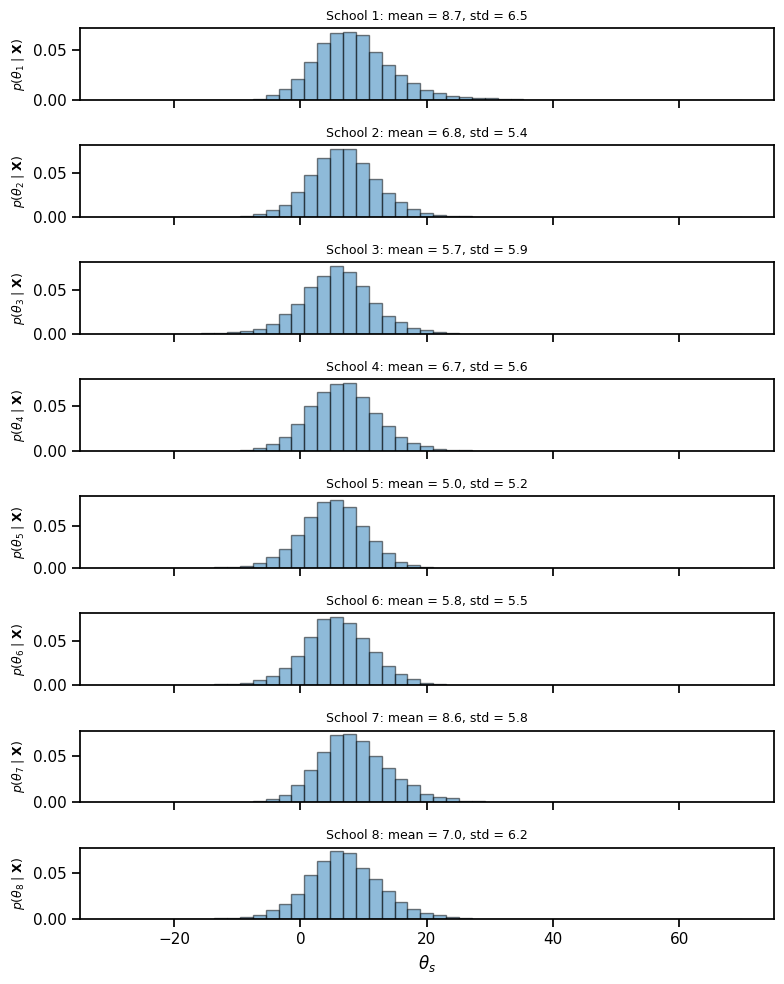

In [20]:
bins = torch.linspace(-30, 70, 50)
fig, axs = plt.subplots(S, 1, figsize=(8, 10), sharex=True)
for s in range(S):
    axs[s].hist(θ_samp[:, s].numpy(), bins.numpy(),
                edgecolor='k', alpha=0.5, density=True)
    if s == S - 1:
        axs[s].set_xlabel(r"$\theta_s$")
    axs[s].set_ylabel(r"$p(\theta_" + str(s+1) + r" \mid \mathbf{X})$", fontsize=9)
    axs[s].set_title(f"School {s+1}: mean = {θ_samp[:,s].mean():.1f}, "
                     f"std = {θ_samp[:,s].std():.1f}", fontsize=9)
plt.tight_layout()

## Comparison to Classical Analysis of Variance

A classical approach to estimating $\theta_s$ offers two extremes:

- **No pooling (unpooled):** $\hat{\theta}_s = \bar{x}_s$. Treat each school independently; ignore any similarity between schools.
- **Complete pooling:** $\hat{\theta}_s = \bar{x}$. Treat all schools as identical; pool all data.

An ANOVA F-test helps choose between them: if the between-group mean square is significantly larger than the within-group mean square, use unpooled estimates; otherwise use pooled.

The hierarchical Bayesian approach **automatically interpolates** between these extremes. The posterior mean $\E[\theta_s \mid \mbX]$ is a precision-weighted blend of the school mean $\bar{x}_s$ and the global mean $\hat{\mu}$, with the blend determined by the posterior over $\tau^2$. When $\tau^2$ is large (schools differ a lot), estimates are close to the unpooled $\bar{x}_s$; when $\tau^2$ is small (schools are similar), estimates shrink toward the pooled mean.

Two advantages of the Bayesian approach:

1. **Uncertainty propagation.** The posterior over $\theta_s$ reflects uncertainty about $\mu$ and $\tau^2$, not just about $\theta_s$ given fixed global parameters. A plug-in estimate $\hat{\tau}^2$ underestimates posterior variance.
2. **Coherence.** The point estimate $\hat{\tau}^2 = (\mathrm{MS}_B - \mathrm{MS}_W)/N$ can be negative (set to zero in practice), which amounts to an overly strong claim that $\tau^2 = 0$. The posterior remains well-behaved.

## Conclusion

The hierarchical Gaussian model demonstrates exact Bayesian inference in a
multi-level setting. The key steps were:

- Express the joint posterior as a product
  $p(\mbtheta \mid \cdot)\, p(\mu \mid \tau^2, \cdot)\, p(\tau^2 \mid \cdot)$
  using the product rule.
- Compute $p(\mbtheta \mid \mu, \tau^2, \cdot)$ and $p(\mu \mid \tau^2, \cdot)$
  analytically using linear Gaussian identities.
- Evaluate and normalize $p(\tau^2 \mid \mbX)$ numerically on a 1D grid.
- Draw samples from the joint posterior via **ancestral sampling**: sample
  $\tau \to \mu \to \mbtheta$ in the order implied by the factorization.

The posterior mean of each $\theta_s$ automatically **partially pools** the
school estimate toward the global mean, with the degree of pooling governed by
the posterior over $\tau^2$.

### Looking Ahead

Exact inference was feasible here because $\tau^2$ is one-dimensional. Extending
the model — allowing unknown within-school variances $\sigma_s^2$, or using a
non-Gaussian likelihood — makes the posterior intractable. The next lecture
introduces **Markov chain Monte Carlo (MCMC)**, beginning with
Metropolis–Hastings and Gibbs sampling, which handle these cases without
requiring analytical tractability.